In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path

data_dir = "/home/solan/repos/airi-research/data"
# data_dir = "/home/HDD12TB/datasets/images/emotions/ACMMM25/AVI/AVI_Challenge_dataset"
DATA_DIR_PATH = Path(data_dir)
PREPROCESSED_TRAIN_DIR_PATH = DATA_DIR_PATH / "preprocessed_train_data"
PREPROCESSED_VAL_DIR_PATH = DATA_DIR_PATH / "preprocessed_val_data"
PREPROCESSED_TEST_DIR_PATH = DATA_DIR_PATH / "preprocessed_test_data"

VIDEO_DIM = 1280
AUDIO_DIM = 1280
TEXT_DIM = 768

In [4]:
import pandas as pd

df_train = pd.read_csv(PREPROCESSED_TRAIN_DIR_PATH / "train_data.csv")
df_val = pd.read_csv(PREPROCESSED_VAL_DIR_PATH / "val_data.csv")
df_test = pd.read_csv(PREPROCESSED_TEST_DIR_PATH / "test_data.csv")

In [5]:
df_train

,id,age,work_experience,Honesty-Humility,Extraversion,Agreeableness,Conscientiousness,Integrity,Collegiality,Social_versatility,...,education_6,education_7,race_0,race_1,race_2,race_3,race_4,race_5,race_6,has_glasses
0,60fccc84440f8e8c82ca0288,0.061224,0.000000,3.781250,3.806250,4.006250,3.668750,4.0,3.9,4.0,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,639881e5774909b88ee9389a,0.693878,0.666667,3.918750,3.475000,3.950000,4.100000,3.6,2.4,2.5,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,60e1d5f866e681d7e33fd01c,0.448980,0.529412,3.075000,2.912500,2.612500,3.562500,3.5,2.5,2.5,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,62ceba5fdab49dfc90278cbb,0.102041,0.098039,3.970000,2.725000,3.312500,3.381250,3.2,3.1,3.3,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,6134113b9f3f724a7cf9e390,0.204082,0.235294,3.037500,2.825000,3.062500,2.931250,3.5,3.5,3.5,...,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,5fbd371dc57ae80a38ba00c2,0.306122,0.196078,3.608333,3.416667,3.716667,3.558333,3.5,4.0,3.7,...,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
446,5a95fee189de8200013eddd4,0.448980,0.392157,3.368750,2.812500,2.912500,2.893750,3.5,2.9,2.9,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
447,629a6460a0232815dab01a01,0.265306,0.137255,3.368750,3.075000,3.443750,3.162500,2.9,3.1,2.9,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
448,5db5dacdb2d499000a8f4439,0.285714,0.254902,3.162500,3.118750,3.643750,3.062500,3.0,3.8,3.5,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [6]:
meta_columns = [
    "age",
    "work_experience",
    *[f"gender_{i}" for i in range(1, 5)],
    *[f"education_{i}" for i in range(1, 8)],
    # extra features
    *[f"race_{i}" for i in range(7)],
    "has_glasses",
]
meta_columns

['age',
 'work_experience',
 'gender_1',
 'gender_2',
 'gender_3',
 'gender_4',
 'education_1',
 'education_2',
 'education_3',
 'education_4',
 'education_5',
 'education_6',
 'education_7',
 'race_0',
 'race_1',
 'race_2',
 'race_3',
 'race_4',
 'race_5',
 'race_6',
 'has_glasses']

In [14]:
df_concated = pd.concat([df_train, df_val])

features = df_concated[meta_columns]
features

,age,work_experience,gender_1,gender_2,gender_3,gender_4,education_1,education_2,education_3,education_4,...,education_6,education_7,race_0,race_1,race_2,race_3,race_4,race_5,race_6,has_glasses
0,0.061224,0.000000,0,1,0,0,0,1,0,0,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.693878,0.666667,1,0,0,0,0,0,1,0,...,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,0.448980,0.529412,0,0,1,0,0,0,1,0,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.102041,0.098039,0,1,0,0,0,0,1,0,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.204082,0.235294,0,1,0,0,0,0,0,1,...,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.081633,0.098039,1,0,0,0,0,0,1,0,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
60,0.469388,0.352941,1,0,0,0,0,0,0,1,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
61,0.489796,0.372549,0,1,0,0,0,0,1,0,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
62,0.306122,0.235294,0,1,0,0,0,0,0,1,...,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [8]:
personality_labels = [
    "Honesty-Humility",
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
]
performance_labels = [
    "Integrity",
    "Collegiality",
    "Social_versatility",
    "Development_orientation",
    "Hireability",
]
postfixes = [
    "_q1_generic",
    "_q2_generic",
    "_q3_personality",
    "_q4_personality",
    "_q5_personality",
    "_q6_personality",
]

In [10]:
import os
import warnings


def load_tensor(path: Path, dim: int):
    if os.path.exists(path):
        tensor = torch.load(f=path, map_location="cpu")
    else:
        warnings.warn(f"Not found on {path}")
        tensor = torch.zeros(dim)

    return tensor


def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    extra = []

    for id, row in df.iterrows():
        for postfix in postfixes:
            video_id = f"{row['id']}{postfix}"

    pass


def prepare_df(df: pd.DataFrame, preprocessed_dir_path: Path) -> pd.DataFrame:
    data = []
    for id, row in df.iterrows():
        for postfix in postfixes:
            video_id = f"{row['id']}{postfix}"

            video_embedding = load_tensor(
                preprocessed_dir_path / "video" / f"{video_id}.pt", VIDEO_DIM
            ).numpy()

            audio_embedding = load_tensor(
                preprocessed_dir_path / "audio" / f"{video_id}.pt", AUDIO_DIM
            ).numpy()

            text_embedding = load_tensor(
                preprocessed_dir_path / "text" / f"{video_id}.pt", TEXT_DIM
            ).numpy()

            assert video_embedding.shape == (
                VIDEO_DIM,
            ), f"{video_embedding.shape = } != {VIDEO_DIM}"
            assert audio_embedding.shape == (
                AUDIO_DIM,
            ), f"{audio_embedding.shape = } != {AUDIO_DIM}"
            assert text_embedding.shape == (
                TEXT_DIM,
            ), f"{audio_embedding.shape = } != {TEXT_DIM}"

            data.append(
                {
                    "video_id": video_id,
                    "video_embedding": video_embedding,
                    "audio_embedding": audio_embedding,
                    "text_embedding": text_embedding,
                    **row[meta_columns],
                    **row[personality_labels],
                    **row[performance_labels],
                }
            )

    df = pd.DataFrame(data)
    video_embedding_df = pd.DataFrame(
        df["video_embedding"]
        .apply(lambda x: pd.Series(x))
        .add_prefix("video_embedding_")
    )
    audio_embedding_df = pd.DataFrame(
        df["audio_embedding"]
        .apply(lambda x: pd.Series(x))
        .add_prefix("audio_embedding_")
    )
    text_embedding_df = pd.DataFrame(
        df["text_embedding"].apply(lambda x: pd.Series(x)).add_prefix("text_embedding_")
    )

    df = pd.concat(
        [df, video_embedding_df, audio_embedding_df, text_embedding_df], axis=1
    ).drop(columns=["video_embedding", "audio_embedding", "text_embedding"])

    return df

In [11]:
df_train_prepared = prepare_df(df_train, PREPROCESSED_TRAIN_DIR_PATH)
df_train_prepared

,video_id,age,work_experience,gender_1,gender_2,gender_3,gender_4,education_1,education_2,education_3,...,text_embedding_758,text_embedding_759,text_embedding_760,text_embedding_761,text_embedding_762,text_embedding_763,text_embedding_764,text_embedding_765,text_embedding_766,text_embedding_767
0,60fccc84440f8e8c82ca0288_q1_generic,0.061224,0.000000,0,1,0,0,0,1,0,...,0.096142,-0.921477,0.825072,0.240941,1.982402,0.535274,-0.181860,-0.093772,-0.256280,-0.267936
1,60fccc84440f8e8c82ca0288_q2_generic,0.061224,0.000000,0,1,0,0,0,1,0,...,-1.296438,-0.641331,0.072822,0.253385,1.077477,0.854237,1.117200,1.119741,-0.308438,-0.471200
2,60fccc84440f8e8c82ca0288_q3_personality,0.061224,0.000000,0,1,0,0,0,1,0,...,-0.674353,-0.147880,-0.212935,0.250764,1.432331,0.031019,0.004382,0.113433,-0.294863,0.195114
3,60fccc84440f8e8c82ca0288_q4_personality,0.061224,0.000000,0,1,0,0,0,1,0,...,-0.290917,-0.733758,-0.208021,0.553123,1.474697,0.582965,0.721032,1.036157,-0.660484,-0.120091
4,60fccc84440f8e8c82ca0288_q5_personality,0.061224,0.000000,0,1,0,0,0,1,0,...,-0.575766,-0.226763,0.219687,0.863166,0.968806,0.784264,0.563985,1.324149,-0.501479,0.113265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,5dcf4136cf8e7e086ea019e4_q2_generic,0.755102,0.607843,0,1,0,0,0,0,0,...,-0.915135,-0.087923,1.092396,0.426978,1.073431,0.755084,1.083986,1.379110,-0.298818,-0.355299
2696,5dcf4136cf8e7e086ea019e4_q3_personality,0.755102,0.607843,0,1,0,0,0,0,0,...,-0.815160,-0.356259,0.947747,0.440619,1.599348,0.764290,0.175387,1.099688,-0.355254,-0.446140
2697,5dcf4136cf8e7e086ea019e4_q4_personality,0.755102,0.607843,0,1,0,0,0,0,0,...,-0.573689,-0.697616,1.410202,0.445274,1.974736,0.791108,0.492092,0.267261,-0.178613,0.088313
2698,5dcf4136cf8e7e086ea019e4_q5_personality,0.755102,0.607843,0,1,0,0,0,0,0,...,-0.358174,-0.159602,0.697456,0.673996,1.208710,0.669012,-0.227742,0.287806,-0.572061,-0.094700


/home/solan/repos/airi-research/data/preprocessed_train_data/video/60fccc84440f8e8c82ca0288_q1_generic/00078.png


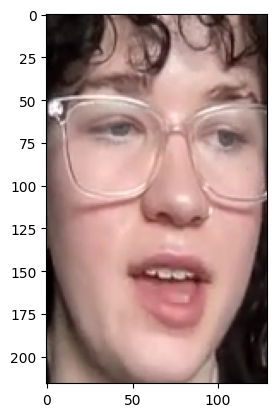

In [12]:
import cv2

# filename = PREPROCESSED_TRAIN_DIR_PATH / "video" / "60fccc84440f8e8c82ca0288_q1_generic"
for image_path in (
    PREPROCESSED_TRAIN_DIR_PATH / "video" / "60fccc84440f8e8c82ca0288_q1_generic"
).glob("*.png"):
    print(image_path)
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    break

## Simple Correlation


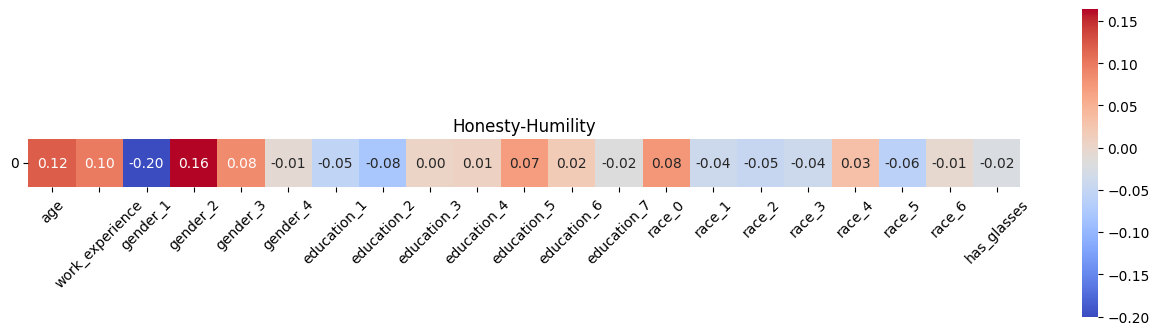

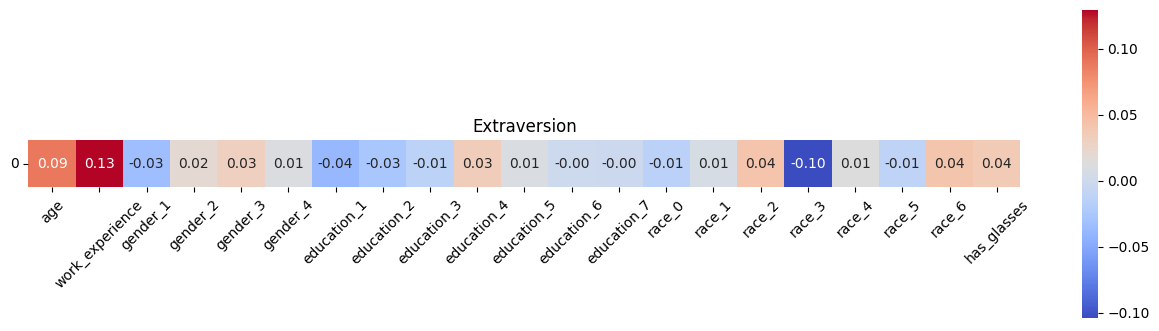

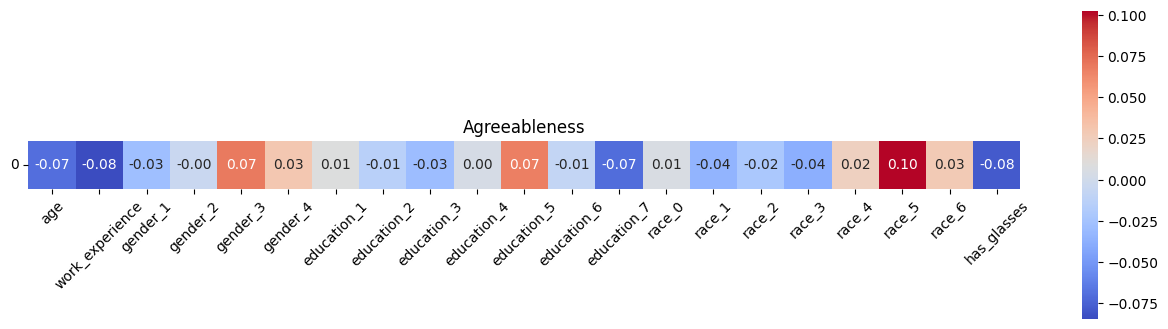

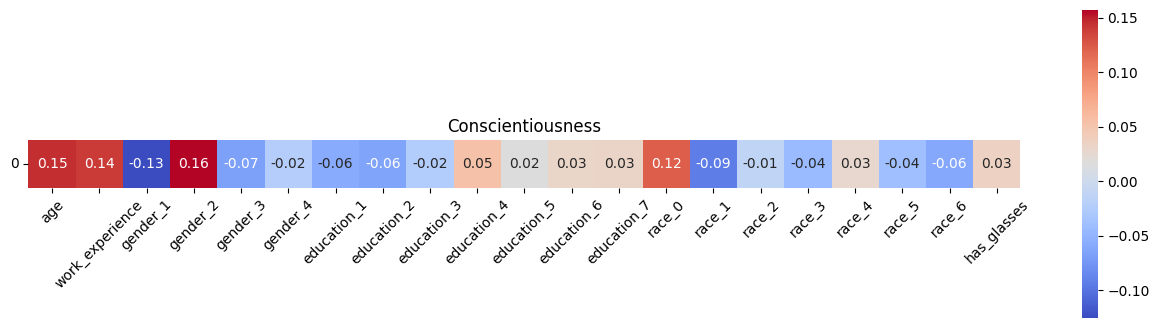

In [15]:
for trait in personality_labels:
    correlations = features.corrwith(df_concated[trait])
    plt.figure(figsize=(16, 4))
    # print(correlations.to_frame().T)
    sns.heatmap(
        correlations.to_frame().T, annot=True, cmap="coolwarm", square=True, fmt=".2f"
    )
    plt.title(trait)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

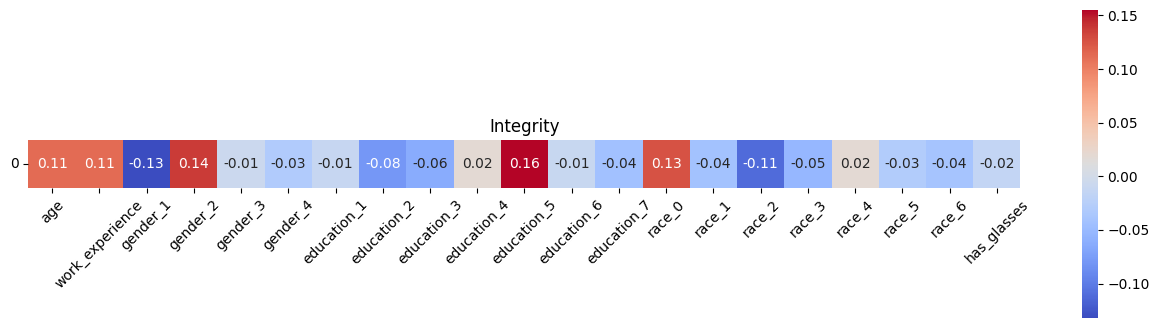

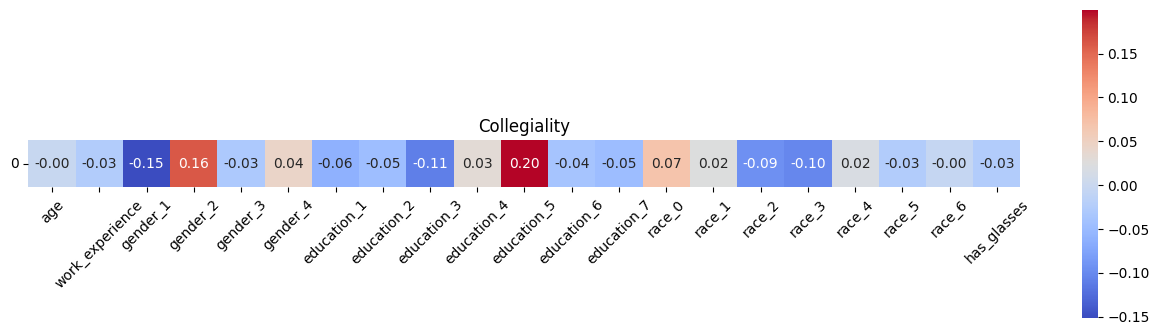

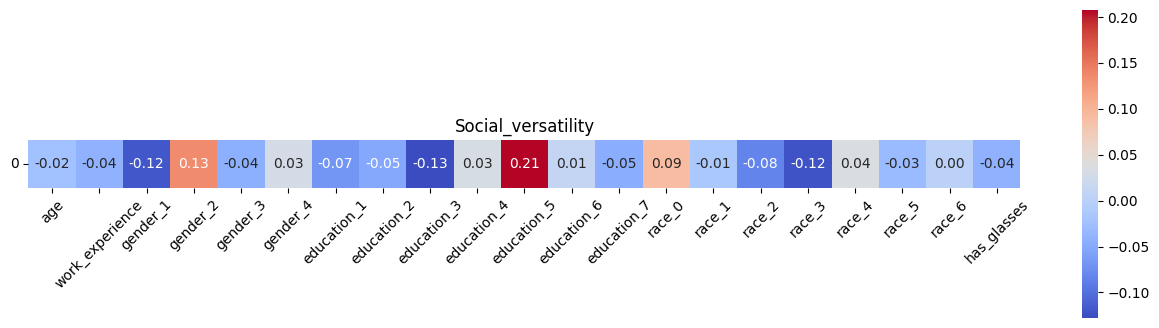

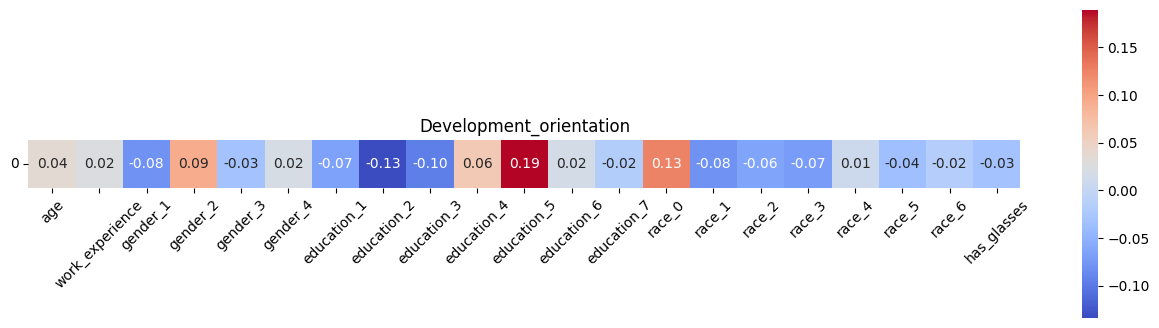

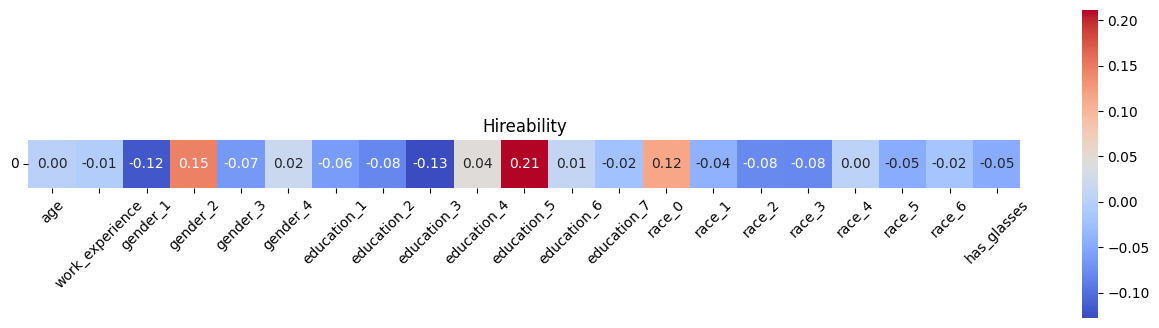

In [16]:
for trait in performance_labels:
    correlations = features.corrwith(df_concated[trait])
    plt.figure(figsize=(16, 4))
    # print(correlations.to_frame().T)
    sns.heatmap(
        correlations.to_frame().T, annot=True, cmap="coolwarm", square=True, fmt=".2f"
    )
    plt.title(trait)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

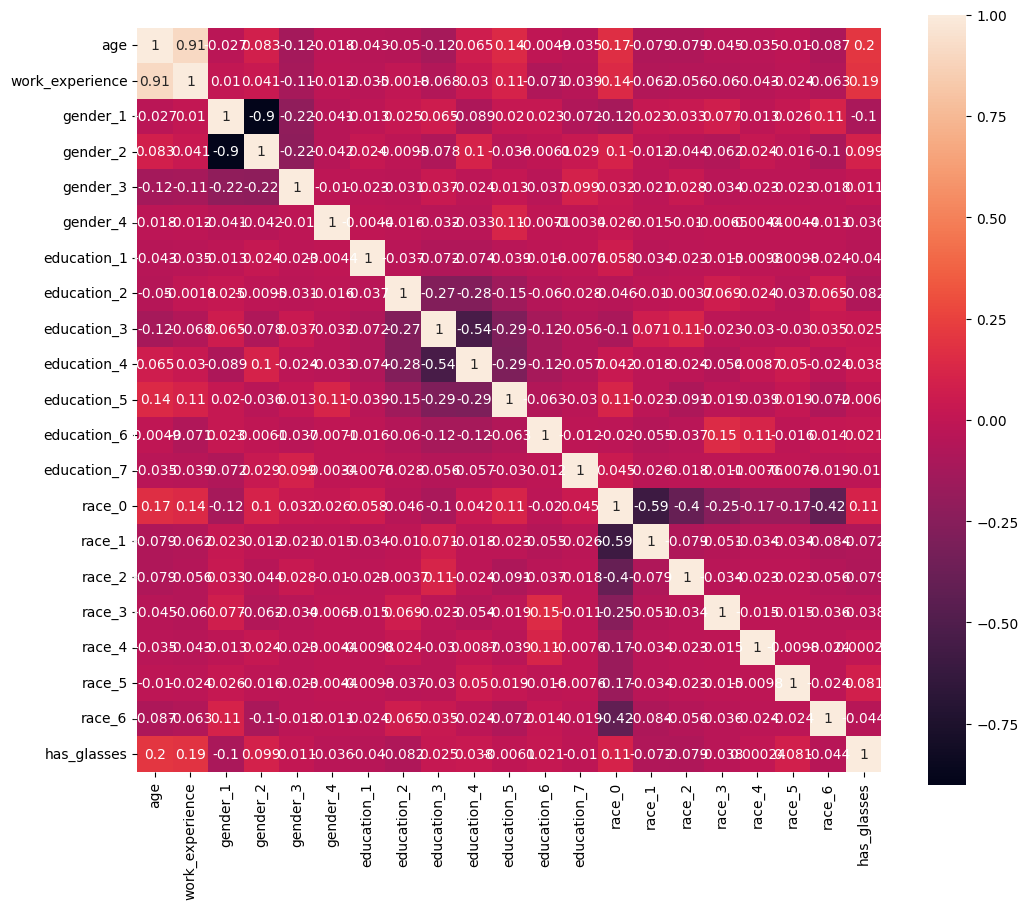

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(features.corr(), square=True, annot=True)
plt.show()